# Sleep Disorder Prediction 

In [1]:
import pandas as pd 
df = pd.read_csv("Sleep_Health_and_Lifestyle_Dataset.csv")
df 

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [2]:
df.shape

(374, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
df["Sleep Disorder"].value_counts(dropna=False) 

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

### Understanding Missing Values in Sleep Disorder
The Sleep Disorder column contains 219 missing (NaN) values.
Based on the structure of the dataset, these NaN values represent individuals with no diagnosed sleep disorder, rather than missing information.
Therefore, we will interpret:
NaN → No Sleep Disorder
Insomnia → Insomnia
Sleep Apnea → Sleep Apnea
We will keep these observations in the dataset because they represent an important group that we want to investigate.
### Research Question
Since a large proportion of individuals have no sleep disorder, we want to investigate:
What factors may explain why some individuals have no sleep disorder while others have Insomnia or Sleep Apnea?

In [5]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")

In [6]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [7]:
df["Sleep Disorder"].value_counts(normalize = True) *100

Sleep Disorder
No Disorder    58.556150
Sleep Apnea    20.855615
Insomnia       20.588235
Name: proportion, dtype: float64

In [8]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [9]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [11]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [12]:
for col in df.select_dtypes(include="object").columns:
    print("\n" + col)
    print(df[col].value_counts())


Gender
Gender
Male      189
Female    185
Name: count, dtype: int64

Occupation
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

BMI Category
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

Blood Pressure
Blood Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
132/87     3
128/85     3
126/83     2
115/78     2
139/91     2
142/92     2
119/77     2
135/88     2
129/84     2
128/84     2
131/86     2
117/76     2
130/86     2
118/75     2
121/79     1
122/80     1
118/76     1
Name: count, dtype: int64

Sleep Disorder
Sleep Disorder
No Disorder    219
Sleep Apnea     

### What factors may explain why some individuals have no sleep disorder while other have Insomnia or Sleep Apnea ?

In [15]:
df.groupby("Sleep Disorder")["Sleep Duration"].mean()

Sleep Disorder
Insomnia       6.589610
No Disorder    7.358447
Sleep Apnea    7.032051
Name: Sleep Duration, dtype: float64

In [16]:
df.groupby("Sleep Disorder")["Sleep Duration"].agg(["mean","median","std"])

,mean,median,std
Sleep Disorder,,,
Insomnia,6.589610,6.5,0.387157
No Disorder,7.358447,7.4,0.732320
Sleep Apnea,7.032051,6.8,0.974812


In [17]:
from scipy.stats import f_oneway

groups = [
    group["Sleep Duration"].values
    for _, group in df.groupby("Sleep Disorder")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 31.913467623717107
p-value: 1.6261510712202572e-13


## Finding 1 — Sleep Duration and Sleep Disorders
The average sleep duration differed across the three sleep disorder groups.
Individuals with no sleep disorder had the highest average sleep duration (7.36 hours).
Individuals with sleep apnea had an average sleep duration of 7.03 hours.
Individuals with insomnia had the lowest average sleep duration (6.59 hours).
A one-way ANOVA showed that the differences in mean sleep duration across the three groups were statistically significant (p < 0.001).
This indicates an association between sleep duration and sleep disorder status in this dataset. However, it does not establish that sleep duration causes a sleep disorder.

In [19]:
df.groupby("Sleep Disorder")["Quality of Sleep"].agg(["mean" ,"median","std"]) 

,mean,median,std
Sleep Disorder,,,
Insomnia,6.532468,7.0,0.804337
No Disorder,7.625571,8.0,0.975142
Sleep Apnea,7.205128,6.0,1.646397


In [20]:
from scipy.stats import f_oneway

groups = [
    group["Quality of Sleep"].values
    for _, group in df.groupby("Sleep Disorder")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 27.600603533974034
p-value: 6.688642015486708e-12


### Finding 2 — Sleep Quality and Sleep Disorders
Sleep quality differed across the three sleep disorder groups.
Individuals with no sleep disorder had the highest average sleep quality score (7.63).
Individuals with sleep apnea had an average score of 7.21.
Individuals with insomnia had the lowest average score of 6.53.
A one-way ANOVA showed that the differences in mean sleep quality across the three groups were statistically significant (p < 0.001).
This indicates an association between sleep quality and sleep disorder status in this dataset. However, it does not establish that sleep quality causes a sleep disorder.

In [21]:
df.groupby("Sleep Disorder")["Stress Level"].agg(["mean","median","std"])

,mean,median,std
Sleep Disorder,,,
Insomnia,5.870130,7.0,1.463150
No Disorder,5.114155,5.0,1.591471
Sleep Apnea,5.666667,7.0,2.333643


In [22]:
from scipy.stats import f_oneway

groups = [
    group["Stress Level"].values
    for _, group in df.groupby("Sleep Disorder")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 6.603565177025682
p-value: 0.00152045905587139


### Finding 3 — Stress Level and Sleep Disorders
Stress levels differed across the three sleep disorder groups.
Individuals with no sleep disorder had the lowest average stress level (5.11).
Individuals with sleep apnea had an average stress level of 5.67.
Individuals with insomnia had the highest average stress level (5.87).
A one-way ANOVA showed that the differences in mean stress level across the three groups were statistically significant (p < 0.05).
This indicates an association between stress level and sleep disorder status in this dataset. However, it does not establish that higher stress causes a sleep disorder.

In [25]:
df.groupby("Sleep Disorder")["Physical Activity Level"].agg(["mean","median","std"])

,mean,median,std
Sleep Disorder,,,
Insomnia,46.818182,45.0,11.751514
No Disorder,57.949772,60.0,20.929814
Sleep Apnea,74.794872,75.0,17.926516


In [26]:
groups = [
    group["Physical Activity Level"].values
    for _, group in df.groupby("Sleep Disorder")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 44.150578634871806
p-value: 6.3061837730488095e-18


### Finding 4 — Physical Activity and Sleep Disorders
Physical activity levels differed across the three sleep disorder groups.
Individuals with insomnia had the lowest average physical activity level (46.82).
Individuals with no sleep disorder had an average level of 57.95.
Individuals with sleep apnea had the highest average level of 74.79.
A one-way ANOVA showed that the differences in mean physical activity level across the three groups were statistically significant (p < 0.001).
This indicates an association between physical activity level and sleep disorder status in this dataset. However, it does not establish that physical activity causes or prevents a sleep disorder.

In [28]:
df.groupby("Sleep Disorder")["Age"].agg(["mean","median","std"])

,mean,median,std
Sleep Disorder,,,
Insomnia,43.519481,44.0,4.808464
No Disorder,39.036530,38.0,7.827764
Sleep Apnea,49.705128,50.0,8.990773


In [29]:
groups = [
    group["Age"].values
    for _, group in df.groupby("Sleep Disorder")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 58.40896314611008
p-value: 8.852104933457365e-23


### Finding 5 — Age and Sleep Disorders
Age differed across the three sleep disorder groups.
Individuals with no sleep disorder had an average age of 39.04 years.
Individuals with insomnia had an average age of 43.52 years.
Individuals with sleep apnea had the highest average age of 49.71 years.
A one-way ANOVA showed that the differences in mean age across the three groups were statistically significant (p < 0.001).
This indicates an association between age and sleep disorder status in this dataset. However, it does not establish that age causes a sleep disorder.

### Overall Finding — Different Profiles Across Sleep Disorder Groups
The analysis revealed that the three sleep disorder groups have different overall profiles across age, sleep, stress, and physical activity.
Individuals with no sleep disorder were younger on average, had longer sleep duration, higher sleep quality, and lower stress levels.
Individuals with insomnia had the lowest average sleep duration and sleep quality, the highest average stress level, and the lowest physical activity level.
Individuals with sleep apnea were older on average and had higher physical activity levels than both other groups. Their average sleep duration and sleep quality were between those of the no-disorder and insomnia groups.
These findings suggest that sleep disorder groups are characterized by different combinations of factors rather than by a single factor alone.
Importantly, these results describe associations within the dataset and do not establish that any of these factors directly cause or prevent sleep disorders.

In [30]:
profile = df.groupby("Sleep Disorder")[
    [
        "Age",
        "Sleep Duration",
        "Quality of Sleep",
        "Stress Level",
        "Physical Activity Level"
    ]
].mean()

profile

,Age,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level
Sleep Disorder,,,,,
Insomnia,43.519481,6.589610,6.532468,5.870130,46.818182
No Disorder,39.036530,7.358447,7.625571,5.114155,57.949772
Sleep Apnea,49.705128,7.032051,7.205128,5.666667,74.794872


In [31]:
profile_z = (profile - profile.mean()) / profile.std()
profile_z

,Age,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level
Sleep Disorder,,,,,
Insomnia,-0.105950,-1.046346,-1.067482,0.817544,-0.925514
No Disorder,-0.942806,0.946103,0.915005,-1.114971,-0.135213
Sleep Apnea,1.048757,0.100244,0.152477,0.297427,1.060727


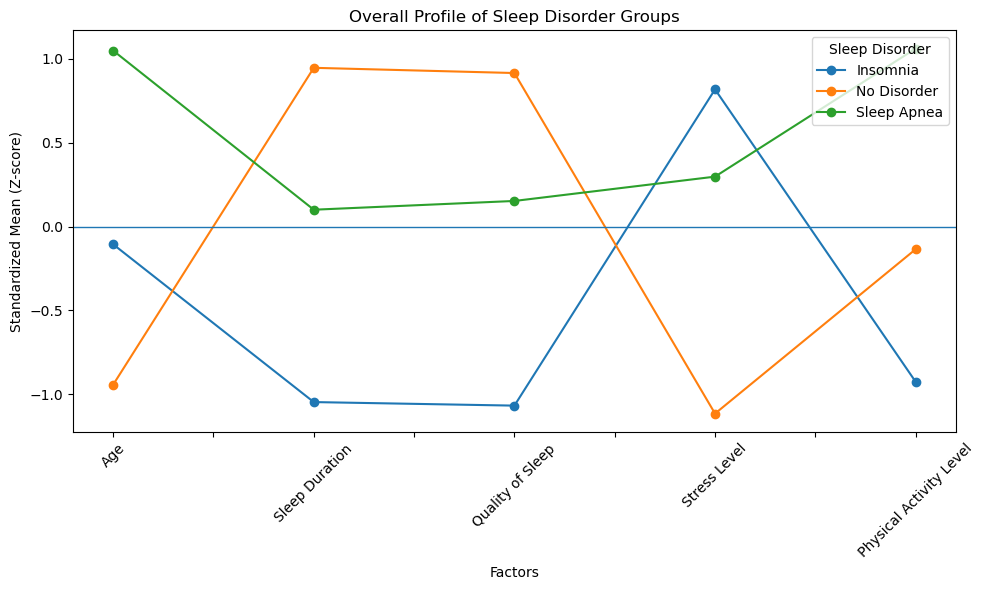

In [32]:
import matplotlib.pyplot as plt

profile_z.T.plot(kind="line", marker="o", figsize=(10, 6))

plt.axhline(0, linewidth=1)
plt.title("Overall Profile of Sleep Disorder Groups")
plt.xlabel("Factors")
plt.ylabel("Standardized Mean (Z-score)")
plt.xticks(rotation=45)
plt.legend(title="Sleep Disorder")
plt.tight_layout()
plt.show()

### the five factors that we found to differ between groups of sleep disorders related to each other ?

In [35]:
factors = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level"
]

correlation_matrix = df[factors].corr()

correlation_matrix

,Age,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level
Age,1.000000,0.344709,0.473734,-0.422344,0.178993
Sleep Duration,0.344709,1.000000,0.883213,-0.811023,0.212360
Quality of Sleep,0.473734,0.883213,1.000000,-0.898752,0.192896
Stress Level,-0.422344,-0.811023,-0.898752,1.000000,-0.034134
Physical Activity Level,0.178993,0.212360,0.192896,-0.034134,1.000000


### Finding 5 — Relationships Between Sleep-Related Factors
The correlation analysis revealed several strong relationships among the investigated factors.
Sleep Duration and Quality of Sleep showed a strong positive correlation (r = 0.883).
Quality of Sleep and Stress Level showed a strong negative correlation (r = -0.899).
Sleep Duration and Stress Level also showed a strong negative correlation (r = -0.811).
Age showed a moderate positive correlation with Quality of Sleep (r = 0.474).
Physical Activity Level showed a very weak correlation with Stress Level (r = -0.034).
Overall, the results suggest that sleep duration, sleep quality, and stress level are strongly interconnected in this dataset. These relationships should be considered when interpreting the factors associated with sleep disorders.

In [43]:
target = "Sleep Disorder"
print(df.columns)
print("\nData types:")
print (df.dtypes)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

Data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


## we want to use the health and behavioral information available about a person to pridect the type of sleep disorder they have

In [45]:
pd.crosstab(
    df["Quality of Sleep"],
    df["Sleep Disorder"],
    normalize="index"
    )

Sleep Disorder,Insomnia,No Disorder,Sleep Apnea
Quality of Sleep,,,
4,0.200000,0.000000,0.800000
5,0.571429,0.000000,0.428571
6,0.304762,0.380952,0.314286
7,0.441558,0.519481,0.038961
8,0.045872,0.926606,0.027523
9,0.014085,0.535211,0.450704


In [46]:
target = "Sleep Disorder"

features = [
    "Gender",
    "Age",
    "Occupation",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Blood Pressure",
    "Heart Rate",
    "Daily Steps"
]

print("Target:", target)
print("\nCandidate Features:")
print(features)

Target: Sleep Disorder

Candidate Features:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps']


In [47]:
categorical_features = [
    "Gender",
    "Occupation",
    "BMI Category",
    "Blood Pressure"
]

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      189
Female    185
Name: count, dtype: int64

--- Occupation ---
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

--- BMI Category ---
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

--- Blood Pressure ---
Blood Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
132/87     3
128/85     3
126/83     2
115/78     2
139/91     2
142/92     2
119/77     2
135/88     2
129/84     2
128/84     2
131/86     2
117/76     2
130/86     2
118/75     2
121/79     1
122/80     1
118/76     1
Name: count, dtype: int64


# Validating Blood Pressure Format

In [50]:
bp_format = df["Blood Pressure"].str.match(r"^\d+/\d+$")

print("Valid Blood Pressure values:", bp_format.sum())
print("Invalid Blood Pressure values:", (~bp_format).sum())

Valid Blood Pressure values: 374
Invalid Blood Pressure values: 0


# Feature Engineering: Blood Pressure

In [51]:
df[["Systolic BP", "Diastolic BP"]] = (
    df["Blood Pressure"]
    .str.split("/", expand=True)
    .astype(int)
)

df[["Blood Pressure", "Systolic BP", "Diastolic BP"]].head()

,Blood Pressure,Systolic BP,Diastolic BP
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


In [52]:
df= df.drop(columns=["Blood Pressure"])
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [54]:
features = [
    "Gender",
    "Age",
    "Occupation",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "BMI Category",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

X = df[features].copy()
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nTarget distribution:")
print(y.value_counts())

Features:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

Target:
Sleep Disorder

Target distribution:
Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size =0.2, random_state=42)
print("Training set:" ,X_train.shape)
print("testing set:" , y_test.shape)

Training set: (299, 12)
testing set: (75,)


In [59]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.5733333333333334


In [60]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

gender_train = encoder.fit_transform(X_train[["Gender"]])
gender_test = encoder.transform(X_test[["Gender"]])

print(gender_train[:5])

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [61]:
encoder_cat = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

categorical_train = encoder_cat.fit_transform(
    X_train[["Occupation", "BMI Category"]]
)

categorical_test = encoder_cat.transform(
    X_test[["Occupation", "BMI Category"]]
)

print("Encoded training shape:", categorical_train.shape)
print("Encoded testing shape:", categorical_test.shape)

Encoded training shape: (299, 15)
Encoded testing shape: (75, 15)


In [63]:
from sklearn.preprocessing import StandardScaler
import numpy as np

numeric_features = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

scaler = StandardScaler()

numeric_train = scaler.fit_transform(X_train[numeric_features])
numeric_test = scaler.transform(X_test[numeric_features])

X_train_encoded = np.hstack([
    gender_train,
    categorical_train,
    numeric_train
])

X_test_encoded = np.hstack([
    gender_test,
    categorical_test,
    numeric_test
])

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (299, 26)
X_test_encoded shape: (75, 26)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9066666666666666


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Insomnia       0.78      0.88      0.82        16
 No Disorder       0.95      0.95      0.95        43
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.91        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.91      0.91      0.91        75



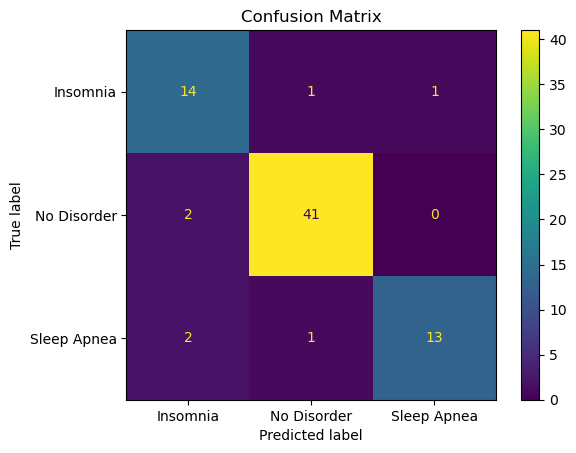

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [67]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_encoded,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV scores: [0.91666667 0.8        0.96666667 0.95       0.89830508]
Mean CV Accuracy: 0.9063276836158194


# Model Interpretation

In [68]:
feature_names = (
    list(encoder.get_feature_names_out(["Gender"]))
    + list(encoder_cat.get_feature_names_out(["Occupation", "BMI Category"]))
    + numeric_features
)

print("Number of feature names:", len(feature_names))
print("Number of model coefficients:", model.coef_.shape[1])

Number of feature names: 26
Number of model coefficients: 26


In [69]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": abs(model.coef_).mean(axis=0)
}).sort_values("Importance", ascending=False)

importance.head(10)

,Feature,Importance
7,Occupation_Nurse,0.845318
9,Occupation_Salesperson,0.732099
2,Occupation_Accountant,0.667074
4,Occupation_Engineer,0.652733
22,Heart Rate,0.633368
12,Occupation_Teacher,0.608849
18,Sleep Duration,0.600469
25,Diastolic BP,0.595264
23,Daily Steps,0.552167
14,BMI Category_Normal Weight,0.496446


# Final Conclusions
Sleep Disorder was associated with differences in age, sleep duration, sleep quality, stress level, and physical activity level.
Sleep Duration, Quality of Sleep, and Stress Level showed strong relationships with each other.
Blood Pressure was transformed into Systolic BP and Diastolic BP for modeling.
The Logistic Regression model achieved 90.67% accuracy on the test set.
5-fold Cross-Validation produced a mean accuracy of 90.63%, which was close to the test accuracy.
The model performed differently across the three sleep-disorder classes, so accuracy alone was not used for evaluation.
Practical Interpretation
The analysis shows that sleep-related and lifestyle variables contain useful patterns for distinguishing between sleep-disorder categories in this dataset.
The model can be viewed as an exploratory data-science tool for identifying patterns in sleep health data. It should not be considered a medical diagnostic tool.
Limitations
The dataset is synthetic, so the findings should not be generalized directly to real-world clinical populations.
The observed relationships represent associations and do not establish causation.
The dataset is relatively small, which can affect model generalization.